In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.7.12


In [2]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd

import statsmodels.api as sm

import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path


from cmdstanpy import set_cmdstan_path
set_cmdstan_path("/home/paleolipidrr/.cmdstan/cmdstan-2.36.0")

from cmdstanpy import cmdstan_path
print(cmdstan_path())

from cmdstanpy import CmdStanModel
import culRIBayesian.stan_utils as culRIB
import culRIBayesian.dataviz_utils as dv
import importlib

import bayspline as bsl
import bayspar as bsr



/home/paleolipidrr/.cmdstan/cmdstan-2.36.0


In [3]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,loN_meso = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(loN_meso,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    loN_meso, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(loN_meso - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.ataN_meso(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient



In [4]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouteN_meso002, schouteN_meso003, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouteN_meso002':(66.6667,-18.6667),
        'schouteN_meso003':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouteN_meso002, schouteN_meso003, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouteN_meso002':(0.015,0.280),
        'schouteN_meso003':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## Logistic equations

In [5]:
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)

In [6]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


In [7]:
# set the path to local folder other than github
login_name = os.getlogin()
### 1.4.1 Local path on PC
local_documents_path = f'/home/{login_name}/Documents' ### this is the path when code is run on Linux

### 1.4.2 Path to github folder
gitpath_idx = os.getcwd().find('culRI-Bayesian')+len('culRI-Bayesian')
local_github_path = os.getcwd()[:gitpath_idx]

### 1.4.3 Path to OneDrive folder
local_onedrive_path = f'/home/{login_name}/OneDrive'


### stan_models path 
stan_models_path = local_github_path+'/culRIBayesian/stan_models/'

# ensure fresh stan models

In [8]:
os.environ["CC"] = "/usr/bin/gcc"
os.environ["CXX"] = "/usr/bin/g++"
os.environ["TBB_CXX_TYPE"] = "gcc"
os.environ["CMDSTAN"] = os.path.expanduser("~/.cmdstan/cmdstan-2.36.0")
from culRIBayesian.stan_utils import refresh_stan_models
refresh_stan_models(stan_models_dir=stan_models_path,n_jobs=8, clean=True)

14:28:17 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox


🔧 (Re)compiling 9 Stan model(s) via CmdStanPy…


14:28:24 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox
14:28:24 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox
14:28:30 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox
14:28:30 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_multiv.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_multiv


✅ Compiled: hier_crtp_univ_priorApprox.stan


14:28:38 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_multiv
14:28:38 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_multiv.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_multiv
14:28:45 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_multiv
14:28:45 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_multiv_meanprior_bayes.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_multiv_meanprior_bayes


...

✅ Compiled: jnt_cul_meso_crtp.stan


14:30:39 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp
14:30:39 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp
14:30:51 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp
14:30:51 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv


✅ Compiled: jnt_cul_meso_hier_crtp.stan


14:31:03 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv
14:31:03 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv
14:31:14 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv


✅ Compiled: jnt_cul_meso_hier_crtp_multiv.stan
🚀 Done compiling Stan models.


In [9]:
### Regression dataset compilation
fpath = fr'{local_github_path}/spreadsheets'
fname = r'culture_mesocosm_combined_rev_030425.csv'

culture_meso_df = pd.read_csv(os.path.join(fpath, fname))
culture_meso_growthrate = culture_meso_df[culture_meso_df['experiment_setup'].isin(['Culture-growth-rate','Culture-oxygen'])].reset_index(drop=True)  
culture_meso_df = culture_meso_df[culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])].reset_index(drop=True)
culture_meso_df['gdgt23ratio'] = culture_meso_df['fGDGT_2']/culture_meso_df['fGDGT_3']
# culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Sinninghe Damste et al. (2002) Journal of Lipid Research'].reset_index(drop=True)
culture_meso_df['Strains_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['Strains'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['Strains_edited'].iloc[i] = culture_meso_df['Strains'].iloc[i]

culture_meso_df['GTDB_genus_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['GTDB_genus'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['GTDB_genus_edited'].iloc[i] = culture_meso_df['GTDB_genus'].iloc[i]

culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences']
culture_meso_df


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,Strains_edited,GTDB_genus_edited
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
126,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
127,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
128,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles


In [10]:
fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
fname = 'woa23_decav91C0_t00_04.nc'

T_da = xr.open_dataset(os.path.join(fpath, fname), decode_times=False)
woas23_sst = T_da.isel(depth=0).t_an
woas23_sst

<xarray.DataArray 't_an' (time: 1, lat: 720, lon: 1440)>
[1036800 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
    depth    float32 0.0
  * time     (time) float32 1.878e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

In [11]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_properties_ds_tmp = xr.open_dataset(os.path.join(fpath, fname))
ocean_properties_ds = xr.merge(
    [ocean_properties_ds_tmp, woas23_sst.rename('sst')],
    compat='override',
    join='override'
)
display(ocean_properties_ds)

fpath = f'{local_github_path}/nc_files/'
fname = 'ds04_gridded_coretop_tex_scaledRI.nc'
coretop_ds = xr.open_dataset(os.path.join(fpath, fname))
coretop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440, time: 1)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
    depth          float32 0.0
  * time           (time) float64 1.878e+03
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
    sst            (time, lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

<xarray.Dataset>
Dimensions:                (lat: 720, lon: 1440)
Coordinates:
  * lat                    (lat) float32 -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon                    (lon) float32 -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables: (12/14)
    region_ID              (lon, lat) float64 ...
    tex_count              (lon, lat) float64 ...
    tex_median             (lon, lat) float64 ...
    tex_mean               (lon, lat) float64 ...
    tex_std                (lon, lat) float64 ...
    scaledRI_count         (lon, lat) float64 ...
    ...                     ...
    scaledRI_std           (lon, lat) float64 ...
    gdgt23ratio_count      (lon, lat) float64 ...
    gdgt23ratio_median     (lon, lat) float64 ...
    gdgt23ratio_mean       (lon, lat) float64 ...
    gdgt23ratio_std        (lon, lat) float64 ...
    modernWaterDepth_mean  (lon, lat) float64 ...
Attributes:
    title:             Gridded coretop TEX86 data
    long_name:         statistics of TEX86 for each grid cell with the same l...
    units:             TEX86 [unitless], Scaled RI [unitless]
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    processing_level:  Derived product
    history:           Computed from the global compilation of core-top GDGT ...
    references:        This study

In [12]:
coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])

coretop_df = coretop_ds_merged.to_dataframe()
coretop_df = coretop_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['scaledRI_median','gdgt23ratio_median',]).reset_index()
coretop_df

,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,gdgt23ratio_mean,gdgt23ratio_std,modernWaterDepth_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,depth,sst
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,1.502839,NaN,928.0,NaN,NaN,-1.636017,30.0,-1.75611,0.0,-1.64841
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,2.833333,NaN,1081.0,NaN,NaN,-1.586854,50.0,-1.66971,0.0,-1.50741
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,1.824832,NaN,332.0,NaN,NaN,-1.692642,30.0,-1.76631,0.0,-1.70171
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,2.066396,NaN,932.0,28.365620,28.426125,-1.498910,10.0,-1.56971,0.0,-1.42831
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,2.040640,NaN,839.0,29.118933,29.757280,-1.651191,40.0,-1.75551,0.0,-1.74881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1469,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,4.516129,NaN,4018.0,7.665815,9.033155,-1.373924,125.0,0.08159,0.0,-1.64041
1470,86.625,152.125,1878.0,3.0,1.0,0.490000,0.490000,NaN,1.0,0.382600,...,21.272727,NaN,1467.0,7.059811,9.083502,-1.156047,175.0,0.24909,0.0,-1.57041
1471,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,9.555556,NaN,3368.0,8.384475,9.424562,-1.477433,150.0,-0.88321,0.0,-1.57180
1472,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,2.870370,NaN,4443.0,6.828367,8.589128,-1.377392,150.0,-0.05211,0.0,-1.73371


In [13]:
# # ─── prepare sample points ────────────────────────────────────────────────────
# xx = np.linspace(-4, 50, 200)

# # ─── filter & group your data ──────────────────────────────────────────────────
# plot_data = culture_meso_df[culture_meso_df['Temperature'] < 50]
# min_count = 2
# groups = [g for g, df in plot_data.groupby('Strains_edited') if len(df) >= min_count]

# # ─── build the figure with one trace per strain per model ─────────────────────
# fig = go.Figure()

# fig.add_trace(go.Scatter(
#     x=coretop_df['t_sf2tc_avg'],
#     y=coretop_df['scaledRI_median'],
#     mode='markers',
#     marker=dict(color='rgba(178,178,178,1.000)', size=5),
#     name='Core-top data',
#     showlegend=True   # you can allow toggling it via legend if you like
# ))
# core_idx = 0  # index of this core-top trace

# # ─── add global fits ────────────────────────────────────────────────
# X_all = plot_data['Temperature'].values.reshape(-1,1)
# y_all = plot_data['scaledRI'].values

# # -- Linear fit --
# ols_all = LinearRegression().fit(X_all, y_all)
# y_lin_all = ols_all.predict(xx.reshape(-1,1))


# # -- Logistic fixed upper --
# p0f = [25, 0.1, 0.1]
# bf = (0, [50,1,1])
# popt_f_all, _ = curve_fit(logistic_fixed_upper, plot_data['Temperature'], plot_data['scaledRI'], p0=p0f, bounds=bf)
# y_logif_all = logistic_fixed_upper(xx, *popt_f_all)
# r2_logif_all = 1 - np.var(plot_data['scaledRI'] - logistic_fixed_upper(plot_data['Temperature'], *popt_f_all)) / np.var(plot_data['scaledRI'])

# # -- Full logistic --
# p0_all = [25,0.1,0.1,0.1]
# bnd_all = (0, [50,1,1,1])
# popt_all, _ = curve_fit(logistic, plot_data['Temperature'], plot_data['scaledRI'], p0=p0_all, bounds=bnd_all)
# y_logi_all = logistic(xx, *popt_all)
# r2_logi_all = 1 - np.var(plot_data['scaledRI'] - logistic(plot_data['Temperature'], *popt_all)) / np.var(plot_data['scaledRI'])

# ## add global fits to figure
# for model, y, r2 in [
#     ("Linear", y_lin_all, ols_all.score(X_all, y_all)),
#     ("Logistic fixed", y_logif_all, r2_logif_all),
#     ("Logistic", y_logi_all, r2_logi_all)
# ]:
#     fig.add_trace(go.Scatter(
#         x=xx, y=y,
#         mode='lines',
#         name=f"glob_cul_meso -- {model} (R²={r2:.2f})",
#         visible=True
#     ))

# ### add X_all and y_all with coretop data and fit the glob_cul_meso_crtp
# X_all_full = np.concatenate((coretop_df['t_sf2tc_avg'].values.reshape(-1,1), plot_data['Temperature'].values.reshape(-1,1)))
# y_all_full = np.concatenate((coretop_df['scaledRI_median'].values, plot_data['scaledRI'].values))

# # -- Linear fit --
# ols_all_full = LinearRegression().fit(X_all_full, y_all_full)
# y_lin_all_full = ols_all_full.predict(xx.reshape(-1,1))
# # -- Logistic fixed upper --
# p0f_full = [25, 0.1, 0.1]
# bf_full = (0, [50,1,1])
# popt_f_all_full, _ = curve_fit(logistic_fixed_upper, np.squeeze(X_all_full), y_all_full, p0=p0f_full, bounds=bf_full)
# y_logif_all_full = logistic_fixed_upper(xx, *popt_f_all_full)
# r2_logif_all_full = 1 - np.var(y_all_full - logistic_fixed_upper(X_all_full, *popt_f_all_full)) / np.var(y_all_full)
# # -- Full logistic --
# p0_all_full = [25,0.1,0.1,0.1]
# bnd_all_full = (0, [50,1,1,1])
# popt_all_full, _ = curve_fit(logistic, np.squeeze(X_all_full), y_all_full, p0=p0_all_full, bounds=bnd_all_full)
# y_logi_all_full = logistic(xx, *popt_all_full)
# r2_logi_all_full = 1 - np.var(y_all_full - logistic(X_all_full, *popt_all_full)) / np.var(y_all_full)
# ## add global fits to figure
# for model, y, r2 in [
#     ("Linear", y_lin_all_full, ols_all_full.score(X_all_full, y_all_full)),
#     ("Logistic fixed", y_logif_all_full, r2_logif_all_full),
#     ("Logistic", y_logi_all_full, r2_logi_all_full)
# ]:
#     fig.add_trace(go.Scatter(
#         x=xx, y=y,
#         mode='lines',
#         name=f"glob_cul_meso_crtp -- {model} (R²={r2:.2f})",
#         visible=True
#     ))
    
# # ─── add all your strain traces ───────────────────────────
# for strain in groups:
#     df = plot_data[plot_data['Strains_edited'] == strain]
#     X = df['Temperature'].values.reshape(-1,1)
#     y = df['scaledRI'].values
    
#     # -- Linear fit --
#     ols = LinearRegression().fit(X, y)
#     y_lin = ols.predict(xx.reshape(-1,1))
#     fig.add_trace(go.Scatter(
#         x=xx, y=y_lin, 
#         mode='lines',
#         name=f"{strain} -- Linear (R²={ols.score(X,y):.2f})",
#         visible=(strain == groups[0])  # only first strain visible initially
#     ))
    
#     # -- Logistic fixed upper --
#     p0f = [25, 0.1, 0.1]
#     bf = (0, [50,1,1])
#     popt_f, _ = curve_fit(logistic_fixed_upper, df['Temperature'], df['scaledRI'], p0=p0f, bounds=bf)
#     y_logf = logistic_fixed_upper(xx, *popt_f)
#     r2_f = 1 - np.var(df['scaledRI'] - logistic_fixed_upper(df['Temperature'], *popt_f)) / np.var(df['scaledRI'])
#     fig.add_trace(go.Scatter(
#         x=xx, y=y_logf,
#         mode='lines',
#         name=f"{strain} -- Logistic fixed (R²={r2_f:.2f})",
#         visible=False
#     ))
    
#     # -- Full logistic --
#     p0 = [25,0.1,0.1,0.1]
#     bnd = (0, [50,1,1,1])
#     popt, _ = curve_fit(logistic, df['Temperature'], df['scaledRI'], p0=p0, bounds=bnd)
#     y_log = logistic(xx, *popt)
#     r2 = 1 - np.var(df['scaledRI'] - logistic(df['Temperature'], *popt)) / np.var(df['scaledRI'])
#     fig.add_trace(go.Scatter(
#         x=xx, y=y_log,
#         mode='lines',
#         name=f"{strain} -- Logistic (R²={r2:.2f})",
#         visible=False
#     ))
    
#     # -- Always-on scatter of raw data --
#     fig.add_trace(go.Scatter(
#         x=df['Temperature'], y=df['scaledRI'],
#         mode='markers',
#         marker=dict(size=6, line=dict(width=1, color='black')),
#         name=f"{strain} -- data",
#         visible=True
#     ))
# # build a mapping strain → color
# palette1 = px.colors.qualitative.Set1
# palette2 = px.colors.qualitative.Set2

# # make one long list
# all_colors = palette1 + palette2

# # then map strains in order
# strain_colors = {
#     strain: all_colors[i % len(all_colors)]
#     for i, strain in enumerate(groups)
# }

# # now loop through all traces
# for trace in fig.data:
#     # The “cultures + mesocosm only” global fit
#     if trace.name.startswith("glob_cul_meso --"):
#         trace.update(line=dict(
#             color="black",   # pick any CSS name or hex code
#             dash="solid",        # “solid”, “dash”, “dot”, “dashdot”, etc
#             width=4              # thicker line
#         ))

#     # The “cultures + mesocosm + coretop” global fit
#     elif trace.name.startswith("glob_cul_meso_crtp --"):
#         trace.update(line=dict(
#             color="black",
#             dash="dashdot",
#             width=3
#         ))
        
#     # skip the core-top (and any other truly global or background traces)
#     elif trace.name == "Core-top data":
#         continue

#     # split off the strain name (everything before the “ – ”)
#     strain = trace.name.split(" -- ")[0]

#     # pick a color: if it’s one of our strains, use its palette color;
#     # otherwise (e.g. “Global”) fall back to black or whatever you like
#     col = strain_colors.get(strain, "black")

#     # apply to both marker & line
#     trace.update(
#         marker=dict(color=col),
#         line=dict(color=col)
#     )



# # Hide all line traces (fits) by default, leave markers visible
# for trace in fig.data:
#     if "lines" in trace.mode:
#         trace.visible = "legendonly"
#     else:
#         trace.visible = True

# # # Make “raw data” the initial visibility state:
# # for tr in fig.data:
# #     if tr.name == "Core-top data" or tr.name.endswith("-- data"):
# #         tr.visible = True
# #     else:
# #         tr.visible = False
        


# # reposition the model‐dropdown as a vertical nav bar on the left
# fig.update_layout(

#     autosize=False,     # turn off responsive “fill the container”
#     width=900,          # fixed pixel width
#     height=500,         # fixed pixel height
#     margin=dict(l=40, r=40, t=50, b=40),

#     title="Scaled RI vs Temperature",
#     xaxis_title="Temperature (°C)",
#     yaxis_title="Scaled RI",
    
#     yaxis=dict(
#         range=[0.1, 1.1],
#         autorange=False    # turn off auto‐scaling
#     ),

#     # put the legend also on the left, so users can click each strain on/off
#     legend=dict(
#         traceorder="normal",
#         orientation="v",
#         x=1.13,      # just inside the left margin
#         y=0.5,
#         xanchor="left",
#         yanchor="middle",
#         itemsizing="constant"
#     ),
#     template='seaborn',
#     font=dict(
#         family="TeX Gyre Heros",
#         size=14,
#         color="black"
#     ),
    
# )

# # lock X/Y so the units match (remove if you don’t want a 1:1 scale)
# fig.update_xaxes(constrain='domain')            # keep the X‐axis from expanding

# # set a default
# # fig.update_layout(template="plotly_white")

# fig.show()

# # in your Python script / notebook:
# fig.write_html(
#   os.path.join(local_github_path, 'html_figures', 'scaledRI_vs_Temperature.html'),
#   include_plotlyjs="cdn",   # pull Plotly.js from the CDN
#   full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
# )


In [14]:
culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture']
culture_data_full = culture_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                        'scaledRI',
                                                                                        'gdgt23ratio']).reset_index(drop=True)
meso_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='mesocosm']
meso_data_full = meso_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                'scaledRI',
                                                                                'gdgt23ratio']).reset_index(drop=True)

coretop_df = coretop_df.replace([np.inf, -np.inf],np.nan).dropna(subset=['scaledRI_median','gdgt23ratio_median']).reset_index(drop=True)
coretop_df = coretop_df[coretop_df['gdgt23ratio_median']<100].reset_index(drop=True)
coretop_df


,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,gdgt23ratio_mean,gdgt23ratio_std,modernWaterDepth_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,depth,sst
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,1.502839,NaN,928.0,NaN,NaN,-1.636017,30.0,-1.75611,0.0,-1.64841
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,2.833333,NaN,1081.0,NaN,NaN,-1.586854,50.0,-1.66971,0.0,-1.50741
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,1.824832,NaN,332.0,NaN,NaN,-1.692642,30.0,-1.76631,0.0,-1.70171
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,2.066396,NaN,932.0,28.365620,28.426125,-1.498910,10.0,-1.56971,0.0,-1.42831
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,2.040640,NaN,839.0,29.118933,29.757280,-1.651191,40.0,-1.75551,0.0,-1.74881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1468,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,4.516129,NaN,4018.0,7.665815,9.033155,-1.373924,125.0,0.08159,0.0,-1.64041
1469,86.625,152.125,1878.0,3.0,1.0,0.490000,0.490000,NaN,1.0,0.382600,...,21.272727,NaN,1467.0,7.059811,9.083502,-1.156047,175.0,0.24909,0.0,-1.57041
1470,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,9.555556,NaN,3368.0,8.384475,9.424562,-1.477433,150.0,-0.88321,0.0,-1.57180
1471,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,2.870370,NaN,4443.0,6.828367,8.589128,-1.377392,150.0,-0.05211,0.0,-1.73371


# Input Data for stan models

In [15]:
t_cul = culture_data_full['Temperature'].astype(float).tolist() 
scaledRI_cul = culture_data_full['scaledRI'].astype(float).tolist() 
gdgt23ratio_cul = culture_data_full['gdgt23ratio'].astype(float).tolist()

t_meso = meso_data_full['Temperature'].astype(float).tolist()
scaledRI_meso = meso_data_full['scaledRI'].astype(float).tolist()
gdgt23ratio_meso = meso_data_full['gdgt23ratio'].astype(float).tolist()



# Calibration posteriors

## jnt_cul_meso

In [ ]:
# # dropna for coretop dataset
# reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
# t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()

# # Save data for Stan
# data = {
#     "N_cul": len(culture_data_full),
#     "t_cul": t_cul,
#     "scaledRI_cul": scaledRI_cul,
#     "N_meso": len(meso_data_full),
#     "t_meso": t_meso,
#     "scaledRI_meso": scaledRI_meso,
#     "N_crtp": len(t_crtp),
#     "t_crtp": t_crtp,
# }

# stan_file_name = 'jnt_cul_meso'
# jnt_cul_meso_post_ds, diag = culRIB.get_posterior(data, 
#                                                   stan_file_name,
#                                                   temptype='cultureT')


# # Save posteriors
# culRIB.save_posterior(jnt_cul_meso_post_ds)

14:31:16 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

14:31:17 - cmdstanpy - INFO - CmdStan done processing.
14:31:17 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_lpdf: Random variable is 3.99313, but must be in the interval [0, 1] (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso.stan', line 31, column 2 to column 29)
	Exception: beta_lpdf: Random variable is 1.20948, but must be in the interval [0, 1] (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso.stan', line 31, column 2 to column 29)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso.stan', line 43, column 2 to column 64)
	Exception: beta_lpdf: Random variable is 2.69441, but must be in the interval [0, 1] (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso.stan', line 31, column 2 to column 29)
Exception: beta_l


Sampling completed in 6.0 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

Posterior saved to /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_cultureT.nc


PosixPath('/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_cultureT.nc')

In [17]:
jnt_cul_meso_post_ds

<xarray.Dataset>
Dimensions:                 (draw: 4000, dim_1: 1464)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
  * dim_1                   (dim_1) int64 0 1 2 3 4 ... 1459 1460 1461 1462 1463
Data variables:
    t0_culmeso              (draw) float64 31.29 29.29 30.49 ... 29.63 30.03
    k_culmeso               (draw) float64 0.1631 0.1558 ... 0.1381 0.1628
    b_culmeso               (draw) float64 0.4635 0.3907 ... 0.3983 0.4366
    sigma_scaledRI_cul      (draw) float64 0.07887 0.08478 ... 0.07524 0.07075
    sigma_scaledRI_meso     (draw) float64 0.1097 0.1167 ... 0.1269 0.09537
    scaledRI_hat            (draw, dim_1) float64 0.466 0.466 ... 0.44 0.4401
    sigma_scaledRI_culmeso  (draw) float64 0.08625 0.0924 ... 0.08863 0.07658
Attributes: (12/21)
    stan_model_name:     jnt_cul_meso
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-06-09T14:31:23.246583
    run_duration (sec):  6.87
    temptype:            cultureT
    ...                  ...
    scaledRI_meso_std:   0.13845152852523196
    scaledRI_meso_min:   0.4640795035
    scaledRI_meso_max:   0.92620505575
    scaledRI_meso_len:   21
    priors:              ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culmeso:...
    filename:            jnt_cul_meso_cultureT

## hier_crtp | prior approximation

In [ ]:
# # dropna for coretop dataset
# reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
# t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
# scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

# prior_mean_t0 = jnt_cul_meso_post_ds["t0_culmeso"].mean(dim="draw").item()
# prior_sd_t0 = jnt_cul_meso_post_ds["t0_culmeso"].std(dim="draw").item()

# prior_mean_k = jnt_cul_meso_post_ds["k_culmeso"].mean(dim="draw").item()
# prior_sd_k = jnt_cul_meso_post_ds["k_culmeso"].std(dim="draw").item()

# prior_mean_b = jnt_cul_meso_post_ds["b_culmeso"].mean(dim="draw").item()
# prior_sd_b = jnt_cul_meso_post_ds["b_culmeso"].std(dim="draw").item()

# data_normal_prior = {
#     "N_crtp": len(t_crtp),
#     "t_crtp": t_crtp,
#     "scaledRI_crtp": scaledRI_crtp,

#     "prior_mean_t0": prior_mean_t0,
#     "prior_sd_t0": prior_sd_t0,
#     "prior_mean_k": prior_mean_k,
#     "prior_sd_k": prior_sd_k,
#     "prior_mean_b": prior_mean_b,
#     "prior_sd_b": prior_sd_b,
# }

# stan_file_name = 'hier_crtp_univ_priorApprox'
# hier_crtp_univ_prior_approx_post_ds, diag = culRIB.get_posterior(data_normal_prior, 
#                                                                  stan_file_name,
#                                                                  temptype='thermoT',)
# # Save posteriors
# culRIB.save_posterior(hier_crtp_univ_prior_approx_post_ds)

# ###################################################
# # dropna for coretop dataset
# reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
# sst_crtp = reg_data['sst'].astype(float).tolist()
# scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

# data_normal_prior = {
#     "N_crtp": len(sst_crtp),
#     "t_crtp": sst_crtp,
#     "scaledRI_crtp": scaledRI_crtp,

#     "prior_mean_t0": prior_mean_t0,
#     "prior_sd_t0": prior_sd_t0,
#     "prior_mean_k": prior_mean_k,
#     "prior_sd_k": prior_sd_k,
#     "prior_mean_b": prior_mean_b,
#     "prior_sd_b": prior_sd_b,
# }

# stan_file_name = 'hier_crtp_univ_priorApprox'
# hier_crtp_sst_univ_prior_approx_post_ds, diag = culRIB.get_posterior(data_normal_prior, 
#                                                                  stan_file_name,
#                                                                  temptype='sst',)
# # Save posteriors
# culRIB.save_posterior(hier_crtp_sst_univ_prior_approx_post_ds)

14:31:24 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

14:31:38 - cmdstanpy - INFO - CmdStan done processing.
14:31:38 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
	Exception: no


Sampling completed in 8.7 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

Posterior saved to /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/hier_crtp_univ_priorApprox_sst.nc


PosixPath('/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/hier_crtp_univ_priorApprox_sst.nc')

## jnt_cul_meso_crtp

In [ ]:
# # dropna for coretop dataset
# reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
# t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
# scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

# ### cul + meso + coretop
# data = {
#     "N_cul": len(culture_data_full),
#     "t_cul": t_cul,
#     "scaledRI_cul": scaledRI_cul,
#     "N_meso": len(meso_data_full),
#     "t_meso": t_meso,
#     "scaledRI_meso": scaledRI_meso,
#     "N_crtp": len(t_crtp),
#     "t_crtp": t_crtp,
#     "scaledRI_crtp": scaledRI_crtp,
# }
# stan_file_name = 'jnt_cul_meso_crtp'
# jnt_cul_meso_crtp_post_ds, diag = culRIB.get_posterior(data, 
#                                                        stan_file_name,
#                                                        temptype='thermoT')
# display(jnt_cul_meso_crtp_post_ds)

# # Save posteriors
# culRIB.save_posterior(jnt_cul_meso_crtp_post_ds)

# ##########################################################
# # dropna for coretop dataset
# reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
# sst_crtp = reg_data['sst'].astype(float).tolist()
# scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

# ### cul + meso + coretop
# data = {
#     "N_cul": len(culture_data_full),
#     "t_cul": t_cul,
#     "scaledRI_cul": scaledRI_cul,
#     "N_meso": len(meso_data_full),
#     "t_meso": t_meso,
#     "scaledRI_meso": scaledRI_meso,
#     "N_crtp": len(sst_crtp),
#     "t_crtp": sst_crtp,
#     "scaledRI_crtp": scaledRI_crtp,
# }
# stan_file_name = 'jnt_cul_meso_crtp'
# jnt_cul_meso_crtp_sst_post_ds, diag = culRIB.get_posterior(data, 
#                                                            stan_file_name,
#                                                            temptype='sst')
# display(jnt_cul_meso_crtp_sst_post_ds)

# # Save posteriors
# culRIB.save_posterior(jnt_cul_meso_crtp_sst_post_ds)


14:31:45 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

14:32:01 - cmdstanpy - INFO - CmdStan done processing.
14:32:01 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_lpdf: Random variable is 3.99313, but must be in the interval [0, 1] (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan', line 42, column 2 to column 65)
	Exception: beta_lpdf: Random variable is 1.23289, but must be in the interval [0, 1] (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan', line 40, column 2 to column 66)
Exception: norm


Sampling completed in 9.7 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



<xarray.Dataset>
Dimensions:              (draw: 4000, dim_1: 1464)
Coordinates:
  * draw                 (draw) int64 0 1 2 3 4 5 ... 3995 3996 3997 3998 3999
  * dim_1                (dim_1) int64 0 1 2 3 4 5 ... 1459 1460 1461 1462 1463
Data variables:
    t0_culmesocore       (draw) float64 29.16 29.16 30.02 ... 29.77 29.53 29.96
    k_culmesocore        (draw) float64 0.1061 0.1104 0.1155 ... 0.1139 0.1127
    b_culmesocore        (draw) float64 0.4134 0.4178 0.4332 ... 0.4271 0.4282
    sigma_scaledRI_cul   (draw) float64 0.08208 0.07847 ... 0.07157 0.08025
    sigma_scaledRI_meso  (draw) float64 0.08081 0.07267 ... 0.07651 0.06484
    sigma_scaledRI_crtp  (draw) float64 0.06099 0.0616 ... 0.06073 0.06156
    scaledRI_hat         (draw, dim_1) float64 0.4349 0.4352 ... 0.4438 0.444
Attributes: (12/25)
    stan_model_name:     jnt_cul_meso_crtp
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-06-09T14:32:06.748680
    run_duration (sec):  10.5
    temptype:            sst
    ...                  ...
    scaledRI_crtp_mean:  0.5558931343738719
    scaledRI_crtp_std:   0.11163760429983549
    scaledRI_crtp_min:   0.26446293775
    scaledRI_crtp_max:   0.8442500000000001
    scaledRI_crtp_len:   1464
    priors:              ['t0_culmesocore: normal(20, 20) T[-4, ]', 'k_culmes...

Posterior saved to /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_crtp_sst.nc


PosixPath('/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_crtp_sst.nc')

## jnt_cul_meso_hier_crtp

In [ ]:
# # dropna for coretop dataset
# reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
# t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
# scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()


# ### cul + meso + coretop
# data = {
#     "N_cul": len(culture_data_full),
#     "t_cul": t_cul,
#     "scaledRI_cul": scaledRI_cul,
#     "N_meso": len(meso_data_full),
#     "t_meso": t_meso,
#     "scaledRI_meso": scaledRI_meso,
#     "N_crtp": len(t_crtp),
#     "t_crtp": t_crtp,
#     "scaledRI_crtp": scaledRI_crtp,

# }
# stan_file_name = 'jnt_cul_meso_hier_crtp'
# jnt_cul_meso_hier_crtp_post_ds, diag = culRIB.get_posterior(data, 
#                                                             stan_file_name,
#                                                             temptype='thermoT',)
# display(jnt_cul_meso_hier_crtp_post_ds)
# # Save posteriors
# culRIB.save_posterior(jnt_cul_meso_hier_crtp_post_ds)

# ###########################################################################
# # dropna for coretop dataset
# reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
# sst_crtp = reg_data['sst'].astype(float).tolist()
# scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

# ### cul + meso + coretop
# data = {
#     "N_cul": len(culture_data_full),
#     "t_cul": t_cul,
#     "scaledRI_cul": scaledRI_cul,
#     "N_meso": len(meso_data_full),
#     "t_meso": t_meso,
#     "scaledRI_meso": scaledRI_meso,
#     "N_crtp": len(sst_crtp),
#     "t_crtp": sst_crtp,
#     "scaledRI_crtp": scaledRI_crtp,

# }
# stan_file_name = 'jnt_cul_meso_hier_crtp'
# jnt_cul_meso_hier_crtp_sst_post_ds, diag = culRIB.get_posterior(data, 
#                                                             stan_file_name,
#                                                             temptype='sst',)
# display(jnt_cul_meso_hier_crtp_sst_post_ds)
# # Save posteriors
# culRIB.save_posterior(jnt_cul_meso_hier_crtp_sst_post_ds)

14:32:07 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

14:32:59 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 13 divergent transitions (1.3%)
	Chain 2 had 5 divergent transitions (0.5%)
	Chain 3 had 10 divergent transitions (1.0%)
	Chain 4 had 9 divergent transitions (0.9%)
	Use function "diagnose()" to see further information.


Sampling completed in 28.4 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
37 of 1000 (3.70%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



<xarray.Dataset>
Dimensions:              (draw: 4000, dim_1: 1464)
Coordinates:
  * draw                 (draw) int64 0 1 2 3 4 5 ... 3995 3996 3997 3998 3999
  * dim_1                (dim_1) int64 0 1 2 3 4 5 ... 1459 1460 1461 1462 1463
Data variables: (12/14)
    t0_culmeso           (draw) float64 28.8 30.87 29.89 ... 29.03 29.69 29.49
    k_culmeso            (draw) float64 0.1411 0.1685 0.1643 ... 0.1563 0.1573
    b_culmeso            (draw) float64 0.4037 0.4393 0.4371 ... 0.3906 0.3956
    t0_crtp              (draw) float64 29.34 29.63 29.43 ... 29.51 29.49 29.5
    k_crtp               (draw) float64 0.1105 0.1033 0.1132 ... 0.1089 0.1111
    b_crtp               (draw) float64 0.4198 0.4158 0.4221 ... 0.4206 0.4207
    ...                   ...
    sigma_b_culmeso      (draw) float64 0.5914 0.1557 1.145 ... 0.2157 0.1818
    sigma_scaledRI_cul   (draw) float64 0.06986 0.07901 ... 0.06961 0.07364
    sigma_scaledRI_meso  (draw) float64 0.1162 0.08523 0.0922 ... 0.1023 0.09882
    sigma_scaledRI_crtp  (draw) float64 0.06149 0.06103 ... 0.06102 0.06139
    mu_scaledRI_crtp     (draw, dim_1) float64 0.4381 0.4384 ... 0.4381 0.4383
    scaledRI_hat         (draw, dim_1) float64 0.4381 0.4384 ... 0.4381 0.4383
Attributes: (12/25)
    stan_model_name:     jnt_cul_meso_hier_crtp
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-06-09T14:33:08.853313
    run_duration (sec):  30.08
    temptype:            sst
    ...                  ...
    scaledRI_crtp_mean:  0.5558931343738719
    scaledRI_crtp_std:   0.11163760429983549
    scaledRI_crtp_min:   0.26446293775
    scaledRI_crtp_max:   0.8442500000000001
    scaledRI_crtp_len:   1464
    priors:              ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culmeso:...

Posterior saved to /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_sst.nc


PosixPath('/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_sst.nc')

['t0', 'k', 'b']


(<Figure size 900x400 with 3 Axes>,
 array([[<AxesSubplot:xlabel='t0'>, <AxesSubplot:xlabel='k'>,
         <AxesSubplot:xlabel='b'>]], dtype=object))

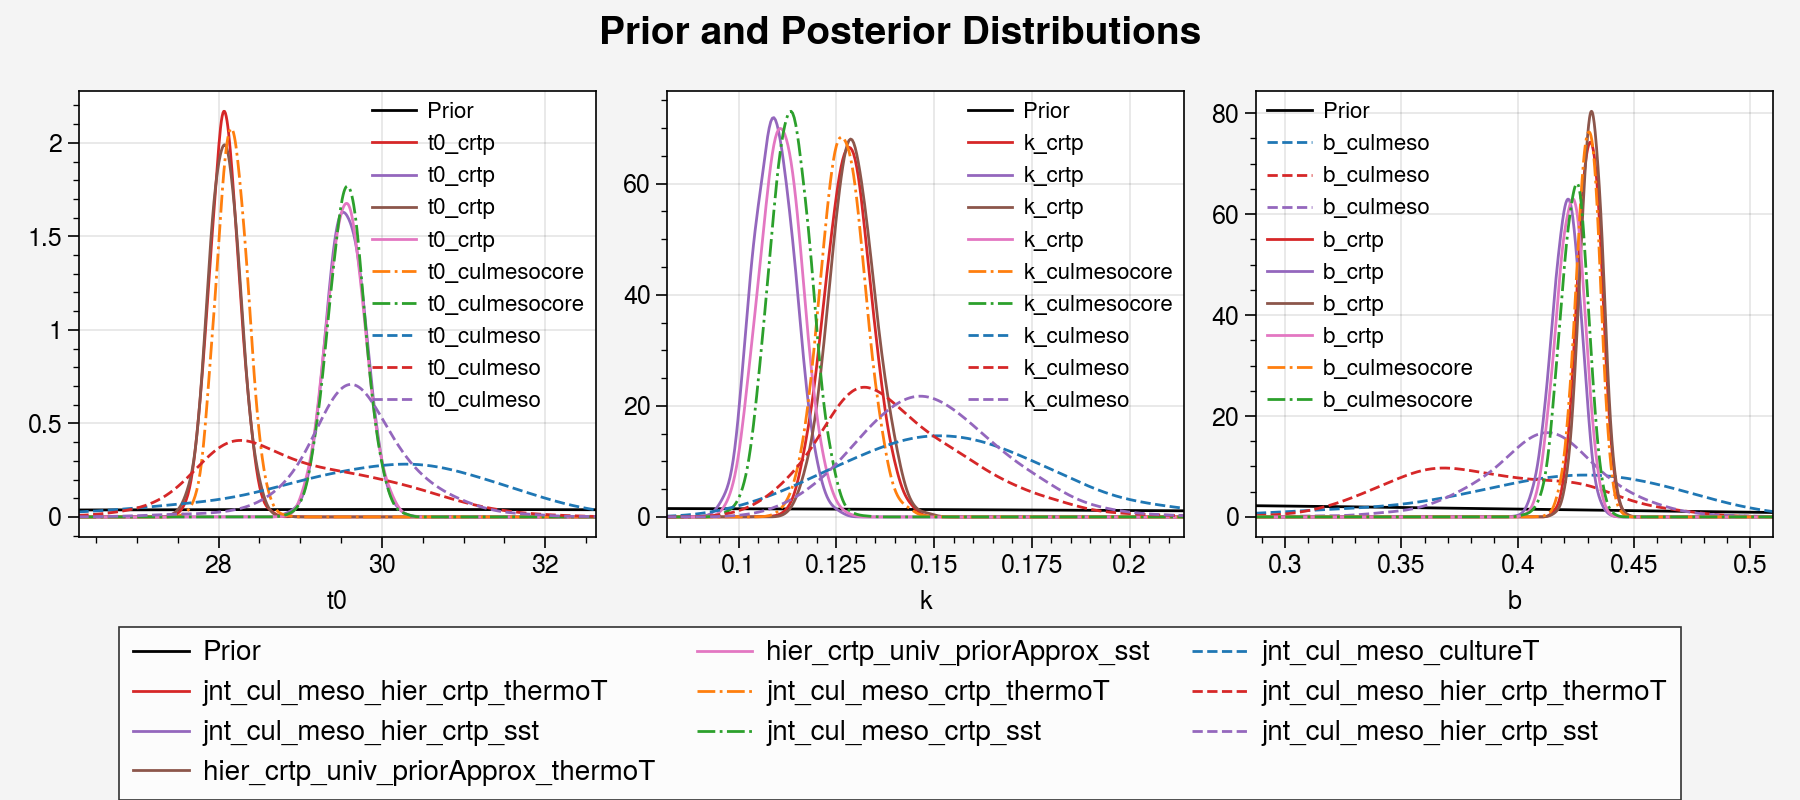

In [ ]:
# priors = jnt_cul_meso_post_ds.attrs['priors']
# dv.plot_prior_distributions(priors,
#                             posterior_datasets=[
#                                 jnt_cul_meso_post_ds,
#                                 jnt_cul_meso_crtp_post_ds,
#                                 jnt_cul_meso_crtp_sst_post_ds,
#                                 jnt_cul_meso_hier_crtp_post_ds,
#                                 jnt_cul_meso_hier_crtp_sst_post_ds,
#                                 # hier_crtp_univ_prior_logmixture_post_ds,
#                                 hier_crtp_univ_prior_approx_post_ds,
#                                 # hier_crtp_sst_univ_prior_logmixture_post_ds,
#                                 hier_crtp_sst_univ_prior_approx_post_ds
#                                 ],
#                             use_linestyle_by_param=True,
#                             show_histogram=False,
#                             set_linewidth=1,
#                             set_bottom_space=0.2,
#                             set_fig_height_factor=4
#                             )

## jnt_cul_meso_hier

In [ ]:
# # dropna for coretop dataset
# reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
# t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
# scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
# gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()

# ### cul + meso + coretop
# data = {
#     "N_cul": len(culture_data_full),
#     "t_cul": t_cul,
#     "scaledRI_cul": scaledRI_cul,
#     "N_meso": len(meso_data_full),
#     "t_meso": t_meso,
#     "scaledRI_meso": scaledRI_meso,
#     "N_crtp": len(t_crtp),
#     "t_crtp": t_crtp,
#     "scaledRI_crtp": scaledRI_crtp,
#     "gdgt23ratio_crtp": gdgt23ratio_crtp,
#     # "no3_crtp": no3_crtp,
#     "no3_cutoff": -1 ## set to -1 to not use no3

# }
# stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
# jnt_cul_meso_hier_crtp_multiv_g23r_post_ds, diag = culRIB.get_posterior(data, 
#                                                                         stan_file_name,
#                                                                         temptype='thermoT')
# display(jnt_cul_meso_hier_crtp_multiv_g23r_post_ds)

# # Save posteriors
# culRIB.save_posterior(jnt_cul_meso_hier_crtp_multiv_g23r_post_ds)

# #####################################################
# # dropna for coretop dataset
# reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
# sst_crtp = reg_data['sst'].astype(float).tolist()
# scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
# gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
# ### cul + meso + coretop
# data = {
#     "N_cul": len(culture_data_full),
#     "t_cul": t_cul,
#     "scaledRI_cul": scaledRI_cul,
#     "N_meso": len(meso_data_full),
#     "t_meso": t_meso,
#     "scaledRI_meso": scaledRI_meso,
#     "N_crtp": len(sst_crtp),
#     "t_crtp": sst_crtp,
#     "scaledRI_crtp": scaledRI_crtp,
#     "gdgt23ratio_crtp": gdgt23ratio_crtp,
#     # "no3_crtp": no3_crtp,
#     "no3_cutoff": -1 ## set to -1 to not use no3

# }
# stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
# jnt_cul_meso_hier_crtp_sst_multiv_g23r_post_ds, diag = culRIB.get_posterior(data, 
#                                                                             stan_file_name,
#                                                                             temptype='sst',)
# display(jnt_cul_meso_hier_crtp_sst_multiv_g23r_post_ds)

# # Save posteriors
# culRIB.save_posterior(jnt_cul_meso_hier_crtp_sst_multiv_g23r_post_ds)

14:33:16 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

14:34:33 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 2 divergent transitions (0.2%)
	Chain 2 had 12 divergent transitions (1.2%)
	Chain 3 had 12 divergent transitions (1.2%)
	Chain 4 had 3 divergent transitions (0.3%)
	Use function "diagnose()" to see further information.


Sampling completed in 38.7 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
29 of 1000 (2.90%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



<xarray.Dataset>
Dimensions:                 (draw: 4000, dim_1: 1464)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
  * dim_1                   (dim_1) int64 0 1 2 3 4 ... 1459 1460 1461 1462 1463
Data variables: (12/16)
    t0_culmeso              (draw) float64 31.33 29.95 31.13 ... 27.85 27.89
    k_culmeso               (draw) float64 0.2037 0.2082 ... 0.1156 0.1334
    b_culmeso               (draw) float64 0.4807 0.4455 ... 0.3452 0.3545
    t0_crtp                 (draw) float64 27.3 27.75 27.61 ... 27.67 27.52 27.8
    k_crtp                  (draw) float64 0.1072 0.1055 ... 0.1053 0.1074
    b_crtp                  (draw) float64 0.4445 0.447 0.4454 ... 0.4429 0.4449
    ...                      ...
    sigma_b_culmeso         (draw) float64 0.1797 0.01545 ... 0.1249 1.108
    sigma_scaledRI_cul      (draw) float64 0.0813 0.0801 ... 0.09139 0.08954
    sigma_scaledRI_meso     (draw) float64 0.09629 0.1085 ... 0.09684 0.08526
    sigma_scaledRI_crtp     (draw) float64 0.0566 0.05826 ... 0.0557 0.05801
    mu_scaledRI_crtp        (draw, dim_1) float64 0.4574 0.4481 ... 0.4232
    scaledRI_hat            (draw, dim_1) float64 0.4574 0.4481 ... 0.4232
Attributes: (12/31)
    stan_model_name:        jnt_cul_meso_hier_crtp_multiv
    generated_by:           culRI-Bayesian
    version:                1.0.0
    run_time:               2025-06-09T14:34:42.694283
    run_duration (sec):     40.42
    temptype:               sst
    ...                     ...
    gdgt23ratio_crtp_std:   3.477076979951923
    gdgt23ratio_crtp_min:   0.7564253358305837
    gdgt23ratio_crtp_max:   35.072441830778935
    gdgt23ratio_crtp_len:   1464
    use_gdgt23ratio:        1
    priors:                 ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culme...

Posterior saved to /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_sst_gdgt23ratio.nc


PosixPath('/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_sst_gdgt23ratio.nc')

In [ ]:
# # dropna for coretop dataset
# reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median','no3_sf2tc_avg']].dropna()
# t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
# scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
# gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
# no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

# no3_cutoff_values = [1, 1.5, 2, 2.5, 5, 10, 15,100]
# for no3_cutoff in no3_cutoff_values:
#     ### cul + meso + coretop
#     data = {
#         "N_cul": len(culture_data_full),
#         "t_cul": t_cul,
#         "scaledRI_cul": scaledRI_cul,
#         "N_meso": len(meso_data_full),
#         "t_meso": t_meso,
#         "scaledRI_meso": scaledRI_meso,
#         "N_crtp": len(t_crtp),
#         "t_crtp": t_crtp,
#         "scaledRI_crtp": scaledRI_crtp,
#         "gdgt23ratio_crtp": gdgt23ratio_crtp,
#         "no3_crtp": no3_crtp,
#         "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

#     }
#     stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
#     jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds, diag = culRIB.get_posterior(data, 
#                                                                                 stan_file_name,
#                                                                                 temptype='thermoT',
#                                                                                 )
#     display(jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds)

#     # Save posteriors
#     culRIB.save_posterior(jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds)

14:34:44 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

14:41:39 - cmdstanpy - INFO - CmdStan done processing.
14:41:39 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 84, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 84, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 85, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 85, column 4 to column 66)
	E

14:41:39 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 28 divergent transitions (2.8%)
	Chain 2 had 10 divergent transitions (1.0%)
	Chain 3 had 9 divergent transitions (0.9%)
	Chain 4 had 7 divergent transitions (0.7%)
	Use function "diagnose()" to see further information.


Sampling completed in 43.0 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
54 of 1000 (5.40%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



<xarray.Dataset>
Dimensions:                 (draw: 4000, dim_1: 1402)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
  * dim_1                   (dim_1) int64 0 1 2 3 4 ... 1397 1398 1399 1400 1401
Data variables: (12/16)
    t0_culmeso              (draw) float64 27.96 28.3 28.5 ... 28.44 28.42 29.28
    k_culmeso               (draw) float64 0.1293 0.1141 ... 0.1694 0.1383
    b_culmeso               (draw) float64 0.3467 0.3633 ... 0.3908 0.3893
    t0_crtp                 (draw) float64 28.05 28.02 27.95 ... 27.79 28.27
    k_crtp                  (draw) float64 0.1232 0.1202 ... 0.1156 0.1139
    b_crtp                  (draw) float64 0.4657 0.469 0.4586 ... 0.4633 0.463
    ...                      ...
    sigma_b_culmeso         (draw) float64 0.654 0.1066 1.019 ... 0.5185 0.4795
    sigma_scaledRI_cul      (draw) float64 0.08603 0.07901 ... 0.07145 0.06819
    sigma_scaledRI_meso     (draw) float64 0.1412 0.08656 ... 0.08478 0.08886
    sigma_scaledRI_crtp     (draw) float64 0.0534 0.05436 ... 0.05447 0.05405
    mu_scaledRI_crtp        (draw, dim_1) float64 0.4436 0.4433 ... 0.4317
    scaledRI_hat            (draw, dim_1) float64 0.4436 0.4433 ... 0.4317
Attributes: (12/38)
    stan_model_name:        jnt_cul_meso_hier_crtp_multiv
    generated_by:           culRI-Bayesian
    version:                1.0.0
    run_time:               2025-06-09T14:41:48.791463
    run_duration (sec):     44.58
    temptype:               thermoT
    ...                     ...
    no3_crtp_min:           0.0002862779365386814
    no3_crtp_max:           33.803863525390625
    no3_crtp_len:           1402
    use_no3:                1
    no3_cutoff:             100.0
    priors:                 ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culme...

Posterior saved to /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_thermoT_gdgt23ratio_no3_100.0.nc


In [ ]:
# # dropna for coretop dataset
# reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median', 'no3_sf2tc_avg']].dropna()
# sst_crtp = reg_data['sst'].astype(float).tolist()
# scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
# gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
# no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

# no3_cutoff_values = [1, 1.5, 2, 2.5, 5, 10, 15, 100]
# for no3_cutoff in no3_cutoff_values:
    
#     ### cul + meso + coretop
#     data = {
#         "N_cul": len(culture_data_full),
#         "t_cul": t_cul,
#         "scaledRI_cul": scaledRI_cul,
#         "N_meso": len(meso_data_full),
#         "t_meso": t_meso,
#         "scaledRI_meso": scaledRI_meso,
#         "N_crtp": len(sst_crtp),
#         "t_crtp": sst_crtp,
#         "scaledRI_crtp": scaledRI_crtp,
#         "gdgt23ratio_crtp": gdgt23ratio_crtp,
#         "no3_crtp": no3_crtp,
#         "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

#     }
#     stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
#     jnt_cul_meso_hier_crtp_sst_multiv_g23r_no3_post_ds, diag = culRIB.get_posterior(data, 
#                                                                                     stan_file_name,
#                                                                                     temptype='sst',
#                                                                                     )
#     display(jnt_cul_meso_hier_crtp_sst_multiv_g23r_no3_post_ds)

#     # Save posteriors
#     culRIB.save_posterior(jnt_cul_meso_hier_crtp_sst_multiv_g23r_no3_post_ds)

14:41:50 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

14:47:25 - cmdstanpy - INFO - CmdStan done processing.
14:47:25 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 84, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 84, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 85, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 85, column 4 to column 66)
	E

14:47:25 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 6 divergent transitions (0.6%)
	Chain 2 had 8 divergent transitions (0.8%)
	Chain 3 had 18 divergent transitions (1.8%)
	Chain 4 had 8 divergent transitions (0.8%)
	Use function "diagnose()" to see further information.


Sampling completed in 41.2 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
40 of 1000 (4.00%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



<xarray.Dataset>
Dimensions:                 (draw: 4000, dim_1: 1402)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
  * dim_1                   (dim_1) int64 0 1 2 3 4 ... 1397 1398 1399 1400 1401
Data variables: (12/16)
    t0_culmeso              (draw) float64 29.53 30.01 30.0 ... 30.38 29.1 28.62
    k_culmeso               (draw) float64 0.1696 0.1449 ... 0.1531 0.1516
    b_culmeso               (draw) float64 0.4088 0.4199 ... 0.3957 0.3984
    t0_crtp                 (draw) float64 29.65 29.76 30.12 ... 29.94 29.99
    k_crtp                  (draw) float64 0.1065 0.1064 0.1075 ... 0.108 0.1081
    b_crtp                  (draw) float64 0.4721 0.4727 ... 0.4654 0.4649
    ...                      ...
    sigma_b_culmeso         (draw) float64 0.1965 0.1599 ... 0.1117 0.08713
    sigma_scaledRI_cul      (draw) float64 0.08023 0.07946 ... 0.07276 0.07277
    sigma_scaledRI_meso     (draw) float64 0.09376 0.0999 ... 0.08905 0.08843
    sigma_scaledRI_crtp     (draw) float64 0.05493 0.05534 ... 0.05723 0.05717
    mu_scaledRI_crtp        (draw, dim_1) float64 0.4441 0.4434 ... 0.4312
    scaledRI_hat            (draw, dim_1) float64 0.4441 0.4434 ... 0.4312
Attributes: (12/38)
    stan_model_name:        jnt_cul_meso_hier_crtp_multiv
    generated_by:           culRI-Bayesian
    version:                1.0.0
    run_time:               2025-06-09T14:47:34.643662
    run_duration (sec):     42.71
    temptype:               sst
    ...                     ...
    no3_crtp_min:           0.0002862779365386814
    no3_crtp_max:           33.803863525390625
    no3_crtp_len:           1402
    use_no3:                1
    no3_cutoff:             100.0
    priors:                 ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culme...

Posterior saved to /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_sst_gdgt23ratio_no3_100.0.nc


In [ ]:
# # dropna for coretop dataset
# reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'no3_sf2tc_avg']].dropna()
# t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
# scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
# no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

# no3_cutoff_values = [1, 1.5, 2, 2.5, 5, 10, 15,100]
# for no3_cutoff in no3_cutoff_values:
#     ### cul + meso + coretop
#     data = {
#         "N_cul": len(culture_data_full),
#         "t_cul": t_cul,
#         "scaledRI_cul": scaledRI_cul,
#         "N_meso": len(meso_data_full),
#         "t_meso": t_meso,
#         "scaledRI_meso": scaledRI_meso,
#         "N_crtp": len(t_crtp),
#         "t_crtp": t_crtp,
#         "scaledRI_crtp": scaledRI_crtp,
#         # "gdgt23ratio_crtp": gdgt23ratio_crtp,
#         "no3_crtp": no3_crtp,
#         "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

#     }
#     stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
#     jnt_cul_meso_hier_crtp_multiv_no3_post_ds, diag = culRIB.get_posterior(data, 
#                                                                             stan_file_name,
#                                                                             temptype='thermoT',
#                                                                             )
#     display(jnt_cul_meso_hier_crtp_multiv_no3_post_ds)

#     # Save posteriors
#     culRIB.save_posterior(jnt_cul_meso_hier_crtp_multiv_no3_post_ds)

14:50:36 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

14:56:14 - cmdstanpy - INFO - CmdStan done processing.
14:56:14 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 84, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 85, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 85, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 84, column 4 to column 63)
	

14:56:15 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 17 divergent transitions (1.7%)
	Chain 2 had 8 divergent transitions (0.8%)
	Chain 3 had 4 divergent transitions (0.4%)
	Chain 4 had 25 divergent transitions (2.5%)
	Use function "diagnose()" to see further information.


Sampling completed in 47.1 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
54 of 1000 (5.40%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



<xarray.Dataset>
Dimensions:                 (draw: 4000, dim_1: 1402)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
  * dim_1                   (dim_1) int64 0 1 2 3 4 ... 1397 1398 1399 1400 1401
Data variables: (12/16)
    t0_culmeso              (draw) float64 29.57 29.51 29.66 ... 29.6 28.93
    k_culmeso               (draw) float64 0.1142 0.1497 0.178 ... 0.1361 0.1389
    b_culmeso               (draw) float64 0.3812 0.4209 ... 0.4192 0.3546
    t0_crtp                 (draw) float64 29.36 29.45 29.57 ... 29.18 29.5
    k_crtp                  (draw) float64 0.1371 0.1344 0.132 ... 0.1285 0.1381
    b_crtp                  (draw) float64 0.4552 0.4608 ... 0.4488 0.4608
    ...                      ...
    sigma_b_culmeso         (draw) float64 0.8426 0.1032 ... 0.3656 0.2243
    sigma_scaledRI_cul      (draw) float64 0.078 0.07252 ... 0.08083 0.07285
    sigma_scaledRI_meso     (draw) float64 0.09887 0.1008 ... 0.1091 0.108
    sigma_scaledRI_crtp     (draw) float64 0.05632 0.0566 ... 0.05748 0.05603
    mu_scaledRI_crtp        (draw, dim_1) float64 0.4287 0.4283 ... 0.4498
    scaledRI_hat            (draw, dim_1) float64 0.4287 0.4283 ... 0.4498
Attributes: (12/32)
    stan_model_name:     jnt_cul_meso_hier_crtp_multiv
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-06-09T14:56:25.810230
    run_duration (sec):  48.79
    temptype:            thermoT
    ...                  ...
    no3_crtp_min:        0.0002862779365386814
    no3_crtp_max:        33.803863525390625
    no3_crtp_len:        1402
    use_no3:             1
    no3_cutoff:          100.0
    priors:              ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culmeso:...

Posterior saved to /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_thermoT_no3_100.0.nc


In [ ]:
# # dropna for coretop dataset
# reg_data = coretop_df[['sst', 'scaledRI_median', 'no3_sf2tc_avg']].dropna()
# sst_crtp = reg_data['sst'].astype(float).tolist()
# scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
# no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

# no3_cutoff_values = [1, 1.5, 2, 2.5, 5, 10, 15, 100]
# for no3_cutoff in no3_cutoff_values:
    
#     ### cul + meso + coretop
#     data = {
#         "N_cul": len(culture_data_full),
#         "t_cul": t_cul,
#         "scaledRI_cul": scaledRI_cul,
#         "N_meso": len(meso_data_full),
#         "t_meso": t_meso,
#         "scaledRI_meso": scaledRI_meso,
#         "N_crtp": len(sst_crtp),
#         "t_crtp": sst_crtp,
#         "scaledRI_crtp": scaledRI_crtp,
#         # "gdgt23ratio_crtp": gdgt23ratio_crtp,
#         "no3_crtp": no3_crtp,
#         "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

#     }
#     stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
#     jnt_cul_meso_hier_crtp_sst_multiv_no3_post_ds, diag = culRIB.get_posterior(data, 
#                                                                                 stan_file_name,
#                                                                                 temptype='sst',
#                                                                                 )
#     display(jnt_cul_meso_hier_crtp_sst_multiv_no3_post_ds)

#     # Save posteriors
#     culRIB.save_posterior(jnt_cul_meso_hier_crtp_sst_multiv_no3_post_ds)

14:56:27 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

15:03:18 - cmdstanpy - INFO - CmdStan done processing.
15:03:18 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 84, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 85, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 85, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 84, column 4 to column 63)
	

15:03:19 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 14 divergent transitions (1.4%)
	Chain 2 had 21 divergent transitions (2.1%)
	Chain 3 had 5 divergent transitions (0.5%)
	Chain 4 had 8 divergent transitions (0.8%)
	Use function "diagnose()" to see further information.


Sampling completed in 42.0 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
48 of 1000 (4.80%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



<xarray.Dataset>
Dimensions:                 (draw: 4000, dim_1: 1402)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
  * dim_1                   (dim_1) int64 0 1 2 3 4 ... 1397 1398 1399 1400 1401
Data variables: (12/16)
    t0_culmeso              (draw) float64 31.03 30.16 31.59 ... 30.88 30.94
    k_culmeso               (draw) float64 0.1469 0.1691 ... 0.1579 0.1507
    b_culmeso               (draw) float64 0.4484 0.431 0.4718 ... 0.4532 0.4403
    t0_crtp                 (draw) float64 31.74 31.57 31.68 ... 31.55 31.45
    k_crtp                  (draw) float64 0.1096 0.1117 ... 0.1115 0.1111
    b_crtp                  (draw) float64 0.452 0.4552 0.4616 ... 0.452 0.4496
    ...                      ...
    sigma_b_culmeso         (draw) float64 0.01688 0.1134 ... 0.02349 0.01484
    sigma_scaledRI_cul      (draw) float64 0.07707 0.06583 ... 0.07266 0.07339
    sigma_scaledRI_meso     (draw) float64 0.08895 0.1007 ... 0.08376 0.07394
    sigma_scaledRI_crtp     (draw) float64 0.05948 0.05946 ... 0.05809 0.05874
    mu_scaledRI_crtp        (draw, dim_1) float64 0.4251 0.4243 ... 0.443 0.4425
    scaledRI_hat            (draw, dim_1) float64 0.4251 0.4243 ... 0.443 0.4425
Attributes: (12/32)
    stan_model_name:     jnt_cul_meso_hier_crtp_multiv
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-06-09T15:03:30.575807
    run_duration (sec):  43.73
    temptype:            sst
    ...                  ...
    no3_crtp_min:        0.0002862779365386814
    no3_crtp_max:        33.803863525390625
    no3_crtp_len:        1402
    use_no3:             1
    no3_cutoff:          100.0
    priors:              ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culmeso:...

Posterior saved to /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_sst_no3_100.0.nc


# Posterior plots --- QC

### 1. Joint culture-mesocosm

['t0', 'k', 'b']


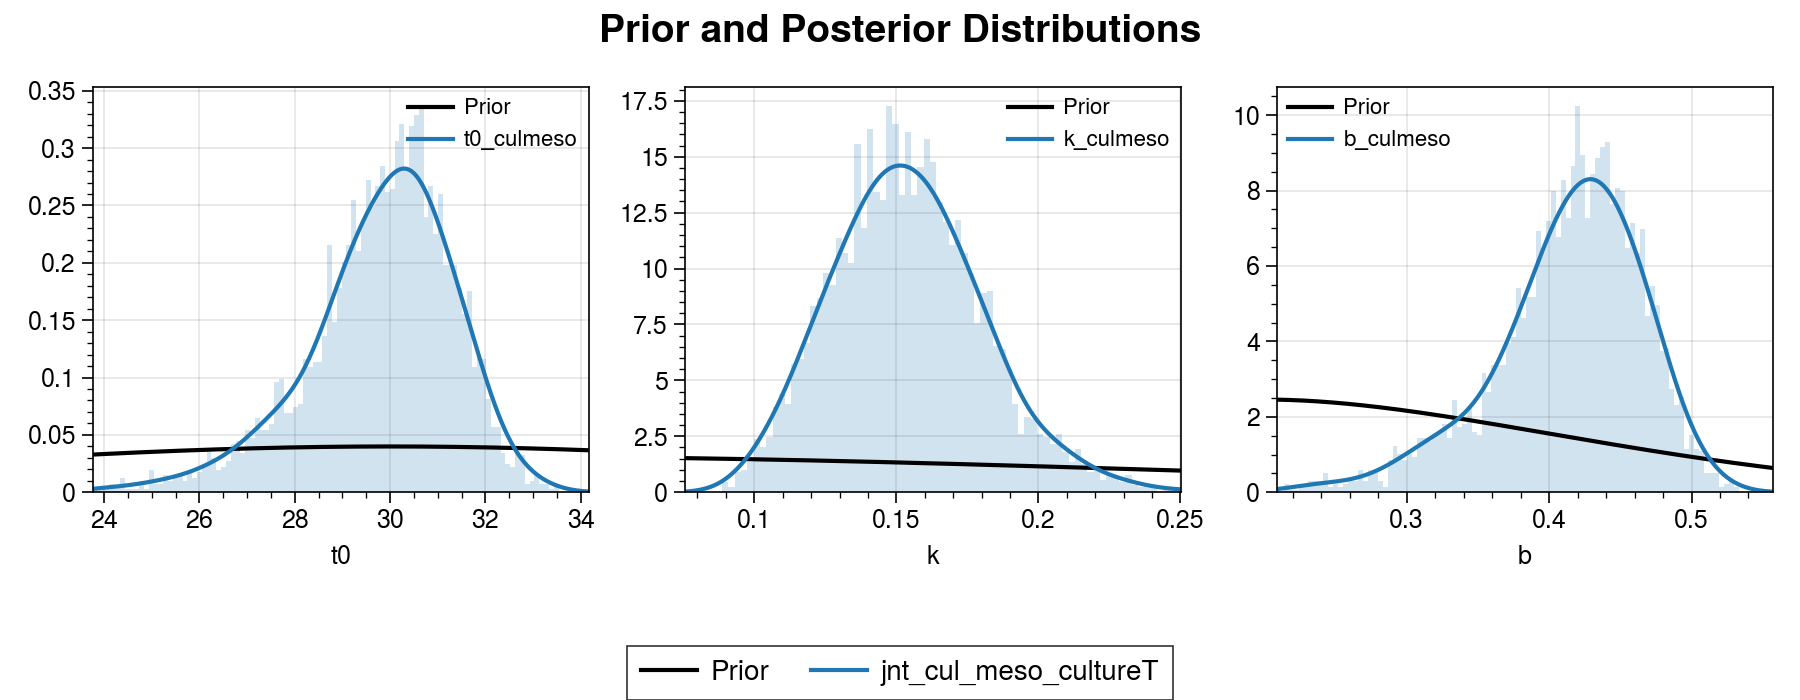

In [31]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[jnt_cul_meso_post_ds]
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


### 2. Joint  culture-mesocosm vs culture-mesocosm-coretop

['t0', 'k', 'b']


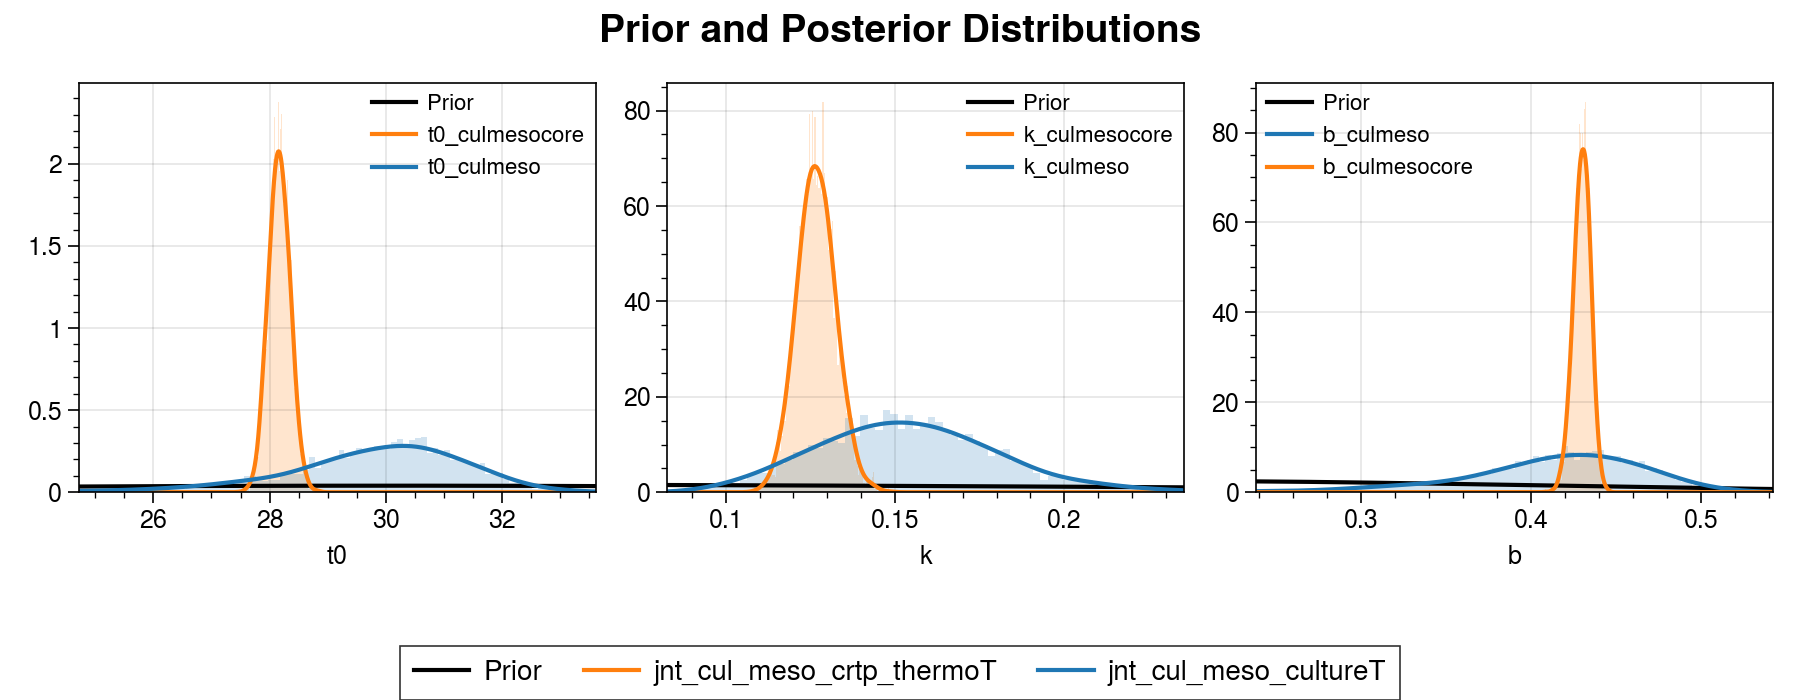

In [32]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        jnt_cul_meso_crtp_post_ds
        ],

)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


### 3. jnt-culture-mesocosm vs jnt-culture-mesocosm-coretop vs jnt-culmeso-hier-crtp

['t0', 'k', 'b']


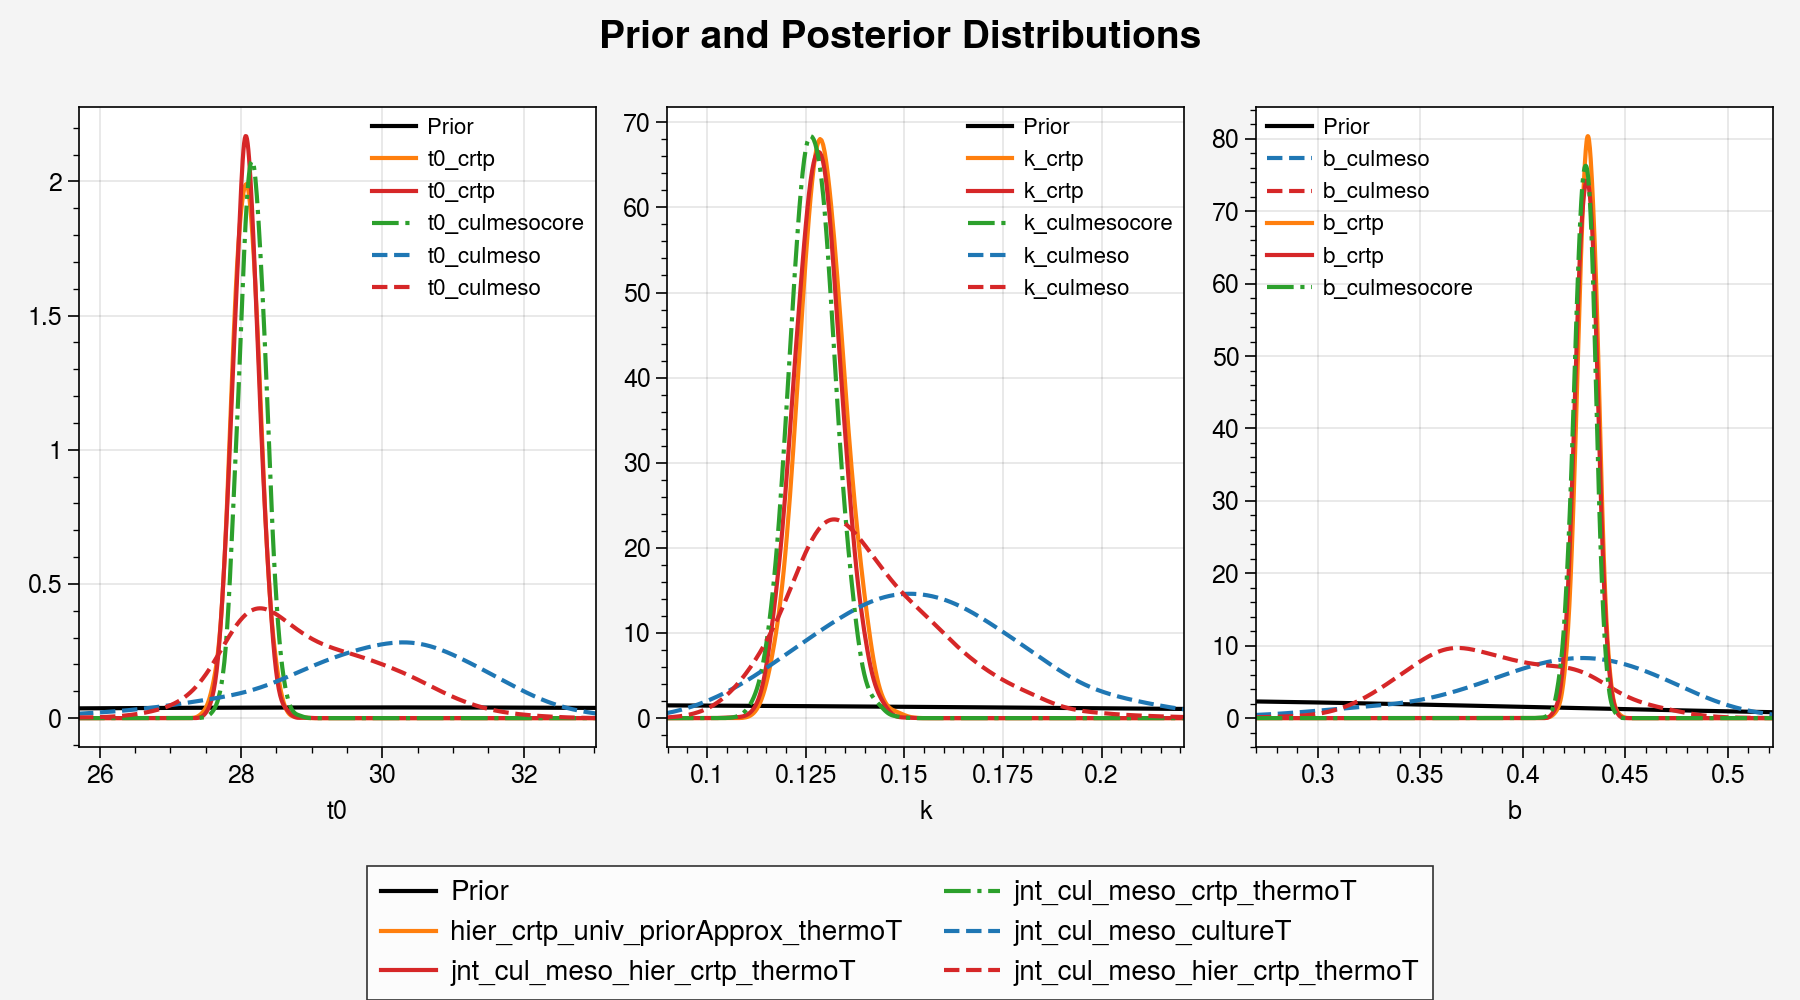

In [33]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        # hier_crtp_univ_prior_logmixture_post_ds,
        hier_crtp_univ_prior_approx_post_ds,
        jnt_cul_meso_crtp_post_ds,
        jnt_cul_meso_hier_crtp_post_ds
        ],
    use_linestyle_by_param=True,
    show_histogram=False,
    set_fig_height_factor=5,
    set_leg_max_ncol=2
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)


['t0', 'k', 'b']


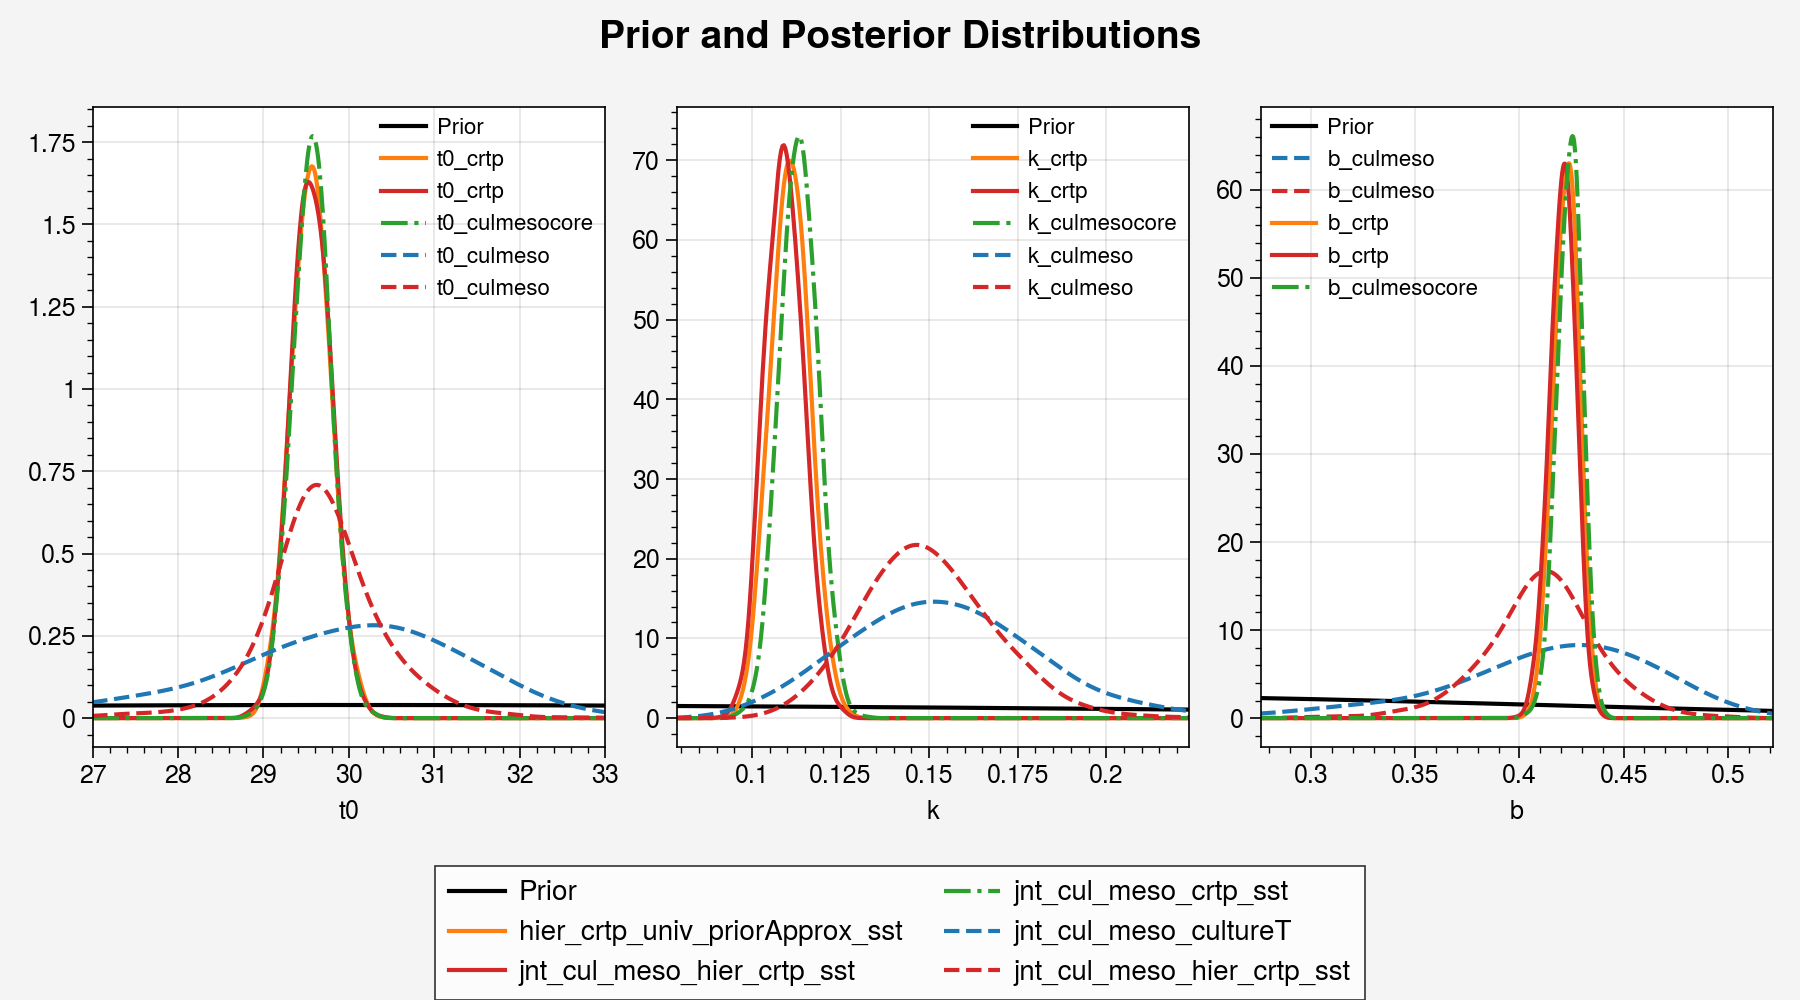

In [34]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        # hier_crtp_univ_prior_logmixture_post_ds,
        hier_crtp_sst_univ_prior_approx_post_ds,
        jnt_cul_meso_crtp_sst_post_ds,
        jnt_cul_meso_hier_crtp_sst_post_ds
        ],
    use_linestyle_by_param=True,
    show_histogram=False,
    set_fig_height_factor=5,
    set_leg_max_ncol=2
)
axes[0][0].set_xlim(27,33)
# Later in notebook
fig.savefig("posterior_check.png", dpi=300)


['t0', 'k', 'b']


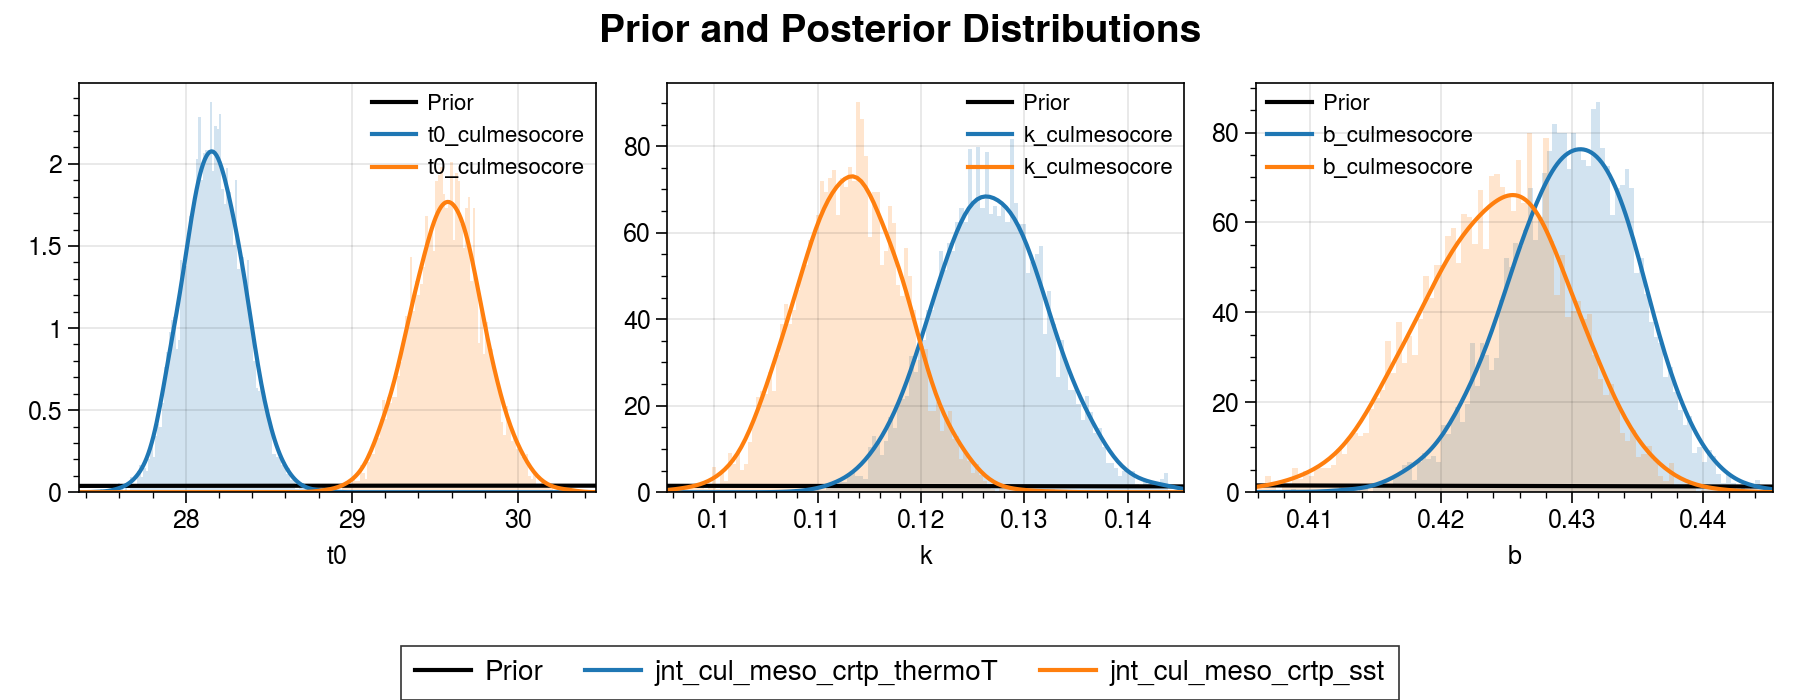

In [35]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_crtp_post_ds,
        jnt_cul_meso_crtp_sst_post_ds
        ],

)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


In [36]:
jnt_cul_meso_post_ds.attrs.get('use_gdgt23ratio',0)

0

In [37]:
stan_file_name = 'jnt_cul_meso_hier_crtp_multiv_thermoT_gdgt23ratio_no3_100.0'
culRIB.load_posterior(stan_file_name)

<xarray.Dataset>
Dimensions:                 (draw: 4000, dim_1: 1402)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
  * dim_1                   (dim_1) int64 0 1 2 3 4 ... 1397 1398 1399 1400 1401
Data variables: (12/16)
    t0_culmeso              (draw) float64 27.96 28.3 28.5 ... 28.44 28.42 29.28
    k_culmeso               (draw) float64 0.1293 0.1141 ... 0.1694 0.1383
    b_culmeso               (draw) float64 0.3467 0.3633 ... 0.3908 0.3893
    t0_crtp                 (draw) float64 28.05 28.02 27.95 ... 27.79 28.27
    k_crtp                  (draw) float64 0.1232 0.1202 ... 0.1156 0.1139
    b_crtp                  (draw) float64 0.4657 0.469 0.4586 ... 0.4633 0.463
    ...                      ...
    sigma_b_culmeso         (draw) float64 0.654 0.1066 1.019 ... 0.5185 0.4795
    sigma_scaledRI_cul      (draw) float64 0.08603 0.07901 ... 0.07145 0.06819
    sigma_scaledRI_meso     (draw) float64 0.1412 0.08656 ... 0.08478 0.08886
    sigma_scaledRI_crtp     (draw) float64 0.0534 0.05436 ... 0.05447 0.05405
    mu_scaledRI_crtp        (draw, dim_1) float64 0.4436 0.4433 ... 0.4317
    scaledRI_hat            (draw, dim_1) float64 0.4436 0.4433 ... 0.4317
Attributes: (12/39)
    stan_model_name:        jnt_cul_meso_hier_crtp_multiv
    generated_by:           culRI-Bayesian
    version:                1.0.0
    run_time:               2025-06-09T14:41:48.791463
    run_duration (sec):     44.58
    temptype:               thermoT
    ...                     ...
    no3_crtp_max:           33.803863525390625
    no3_crtp_len:           1402
    use_no3:                1
    no3_cutoff:             100.0
    priors:                 ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culme...
    filename:               jnt_cul_meso_hier_crtp_multiv_thermoT_gdgt23ratio...

['t0', 'k', 'b', 'beta0_gdgt23ratio', 'beta0_no3']


(25.0, 35.0)

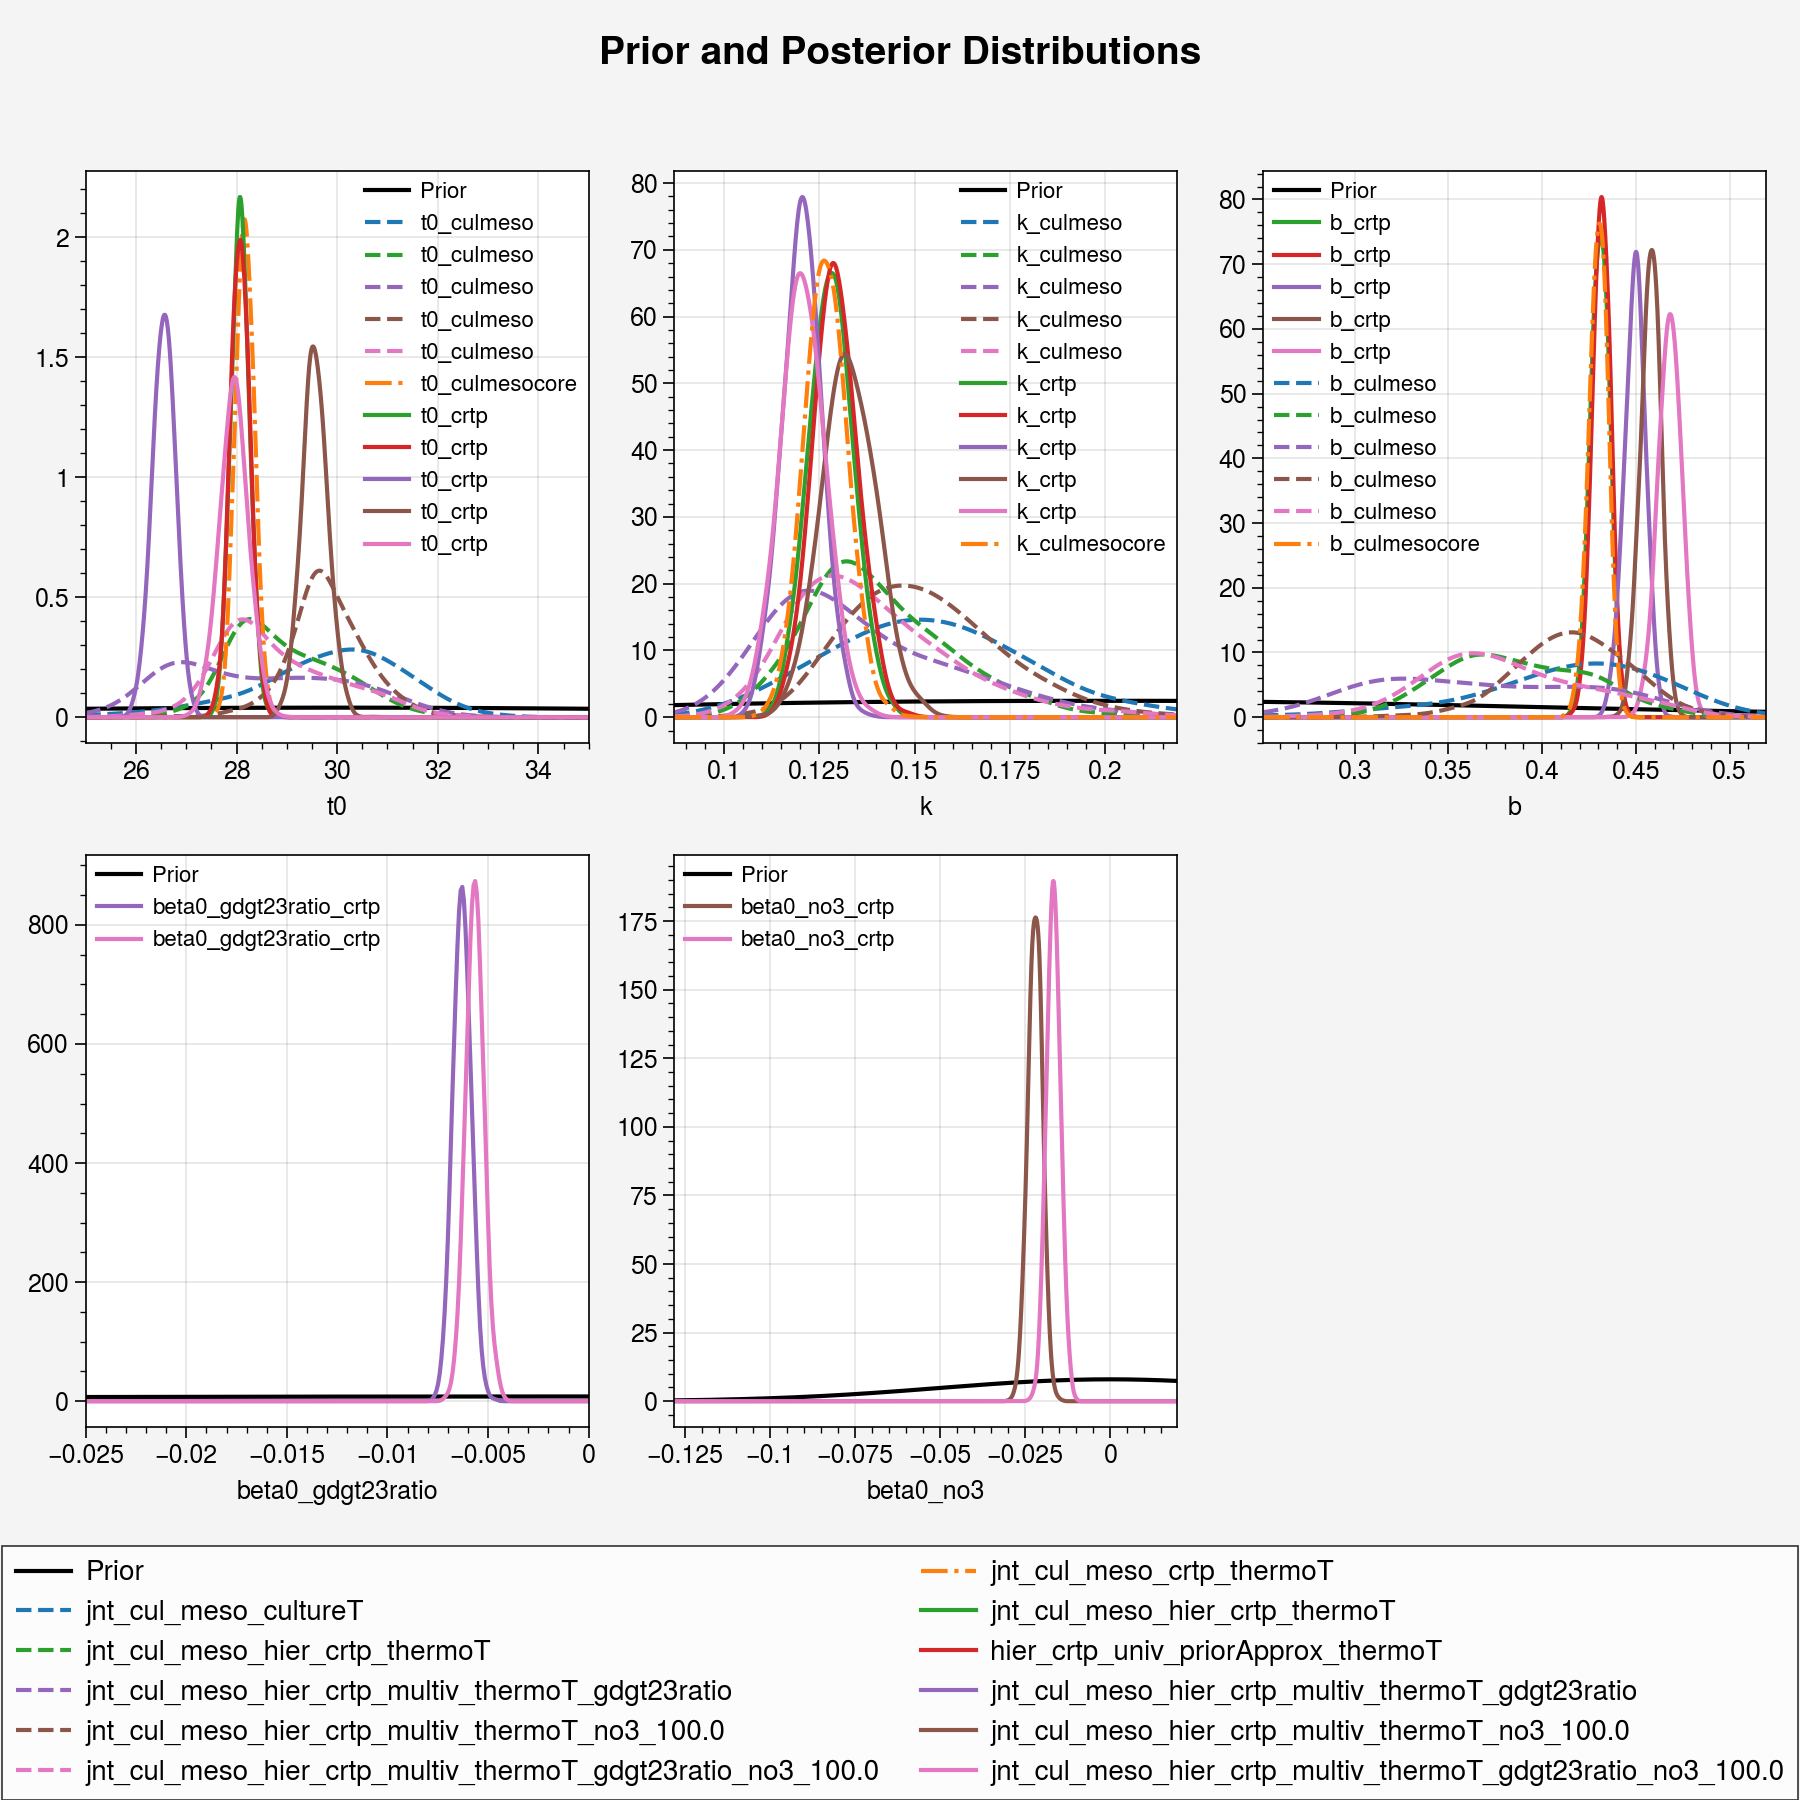

In [38]:
priors = jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds.attrs['priors']

fig, axes = dv.plot_prior_distributions(
                priors,
                posterior_datasets=[
                    jnt_cul_meso_post_ds,
                    jnt_cul_meso_crtp_post_ds,
                    jnt_cul_meso_hier_crtp_post_ds,
                    hier_crtp_univ_prior_approx_post_ds,
                    jnt_cul_meso_hier_crtp_multiv_g23r_post_ds,
                    jnt_cul_meso_hier_crtp_multiv_no3_post_ds,
                    jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds,
                    ],

                # focus_on_posterior=False,
                use_linestyle_by_param=True,
                show_histogram=False,
                set_leg_max_ncol=2,
                set_fig_height_factor=4.5,
                # suffix_include=["crtp","culmesocore"]
                )

axes[1][0].set_xlim(-0.025,0)
axes[0][0].set_xlim(25,35)

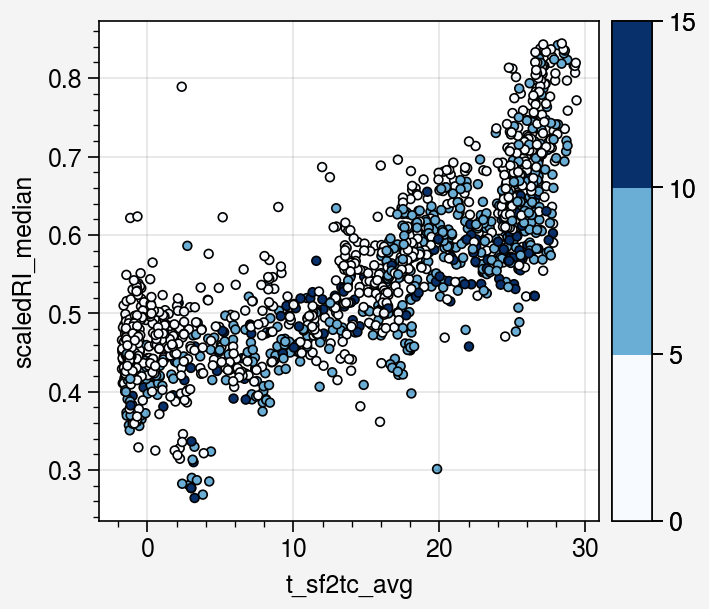

In [39]:
fig,  axs = plot.subplots()

ax = axs[0]
plot_x = coretop_df['t_sf2tc_avg']
plot_y = coretop_df['scaledRI_median']
plot_c = coretop_df['gdgt23ratio_median']
m = ax.scatter(plot_x, plot_y, s=10, c=plot_c, mec='k', cmap='blues', levels=[0,5,10,15], label='Core-top data')
ax.colorbar(m, loc='r')